In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
import numpy as np

In [2]:
file = "dvi_dim.csv"

In [3]:
df = pd.read_csv(file)
labels = df.columns.to_list()
if 'label' in labels:
    X = df.drop(columns=['label']).values
else:
    X = df.values

In [4]:
if file == "dvi_dim.csv":
   X_tsne = np.array(X)
elif file == "norm_full_no_outliers.csv":
   perp = 50
   learn_r = 200
   early_ex = 24
elif file == "norm_6_no_outliers.csv":
   perp = 50
   learn_r = 50
   early_ex = 12

In [65]:
if file == "dvi_dim_lbl.csv":
   X_tsne = np.array(X)
elif file == "norm_full.csv":
   perp = 50
   learn_r = 200
   early_ex = 24
elif file == "norm_6.csv":
   perp = 50
   learn_r = 50
   early_ex = 12

dbscan parametrai: <br>
**norm6:** <br>
eps = 0.1 ir min_samples = 5 <br>
**norm full:** <br>
eps=0,16; min_samples=20 <br>
**dvivim:** <br>
eps = 1.2, min_samples = 12. <br>

In [8]:
dbscan = DBSCAN(eps=1.2, min_samples=12, metric="euclidean")
labels = dbscan.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Rasta klasterių (be triukšmo): {n_clusters}")

Rasta klasterių (be triukšmo): 29


In [9]:
if file != "dvi_dim_lbl.csv":
    tsne = TSNE(
        n_components=2,         # sumažiname duomenų dimensijų skaičių iki 2
        perplexity=perp,          # kiek artimiausių kaimynų laikoma reikšmingais
        learning_rate=learn_r,      # nustato, kokio dydžio korekcijos taikomos kiekviename iteracijos žingsnyje
        max_iter=1000,            # iteracijų skaičius: kiek gradientinio nusileidimo žingsnių atliekama minimizuojant klaidą
        early_exaggeration=early_ex,# padeda atskirti klasterius ir išvengti lokalių minimumų
        metric="euclidean",     # atstumo metrika pradinėje erdvėje
        random_state=67,        # kad rezultatai būtų atkuriami (užtikrina tą pačią pradinę taškų padėtį)
        init="pca"              # pradinė taškų pozicija nustatoma PCA pagrindu (stabiliau nei random)
    )

    X_tsne = tsne.fit_transform(X)

NameError: name 'perp' is not defined

/var/folders/8m/2mjbvkv91xx273zl_4n42rsr0000gn/T/ipykernel_4843/1854948387.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(1, n_clusters))


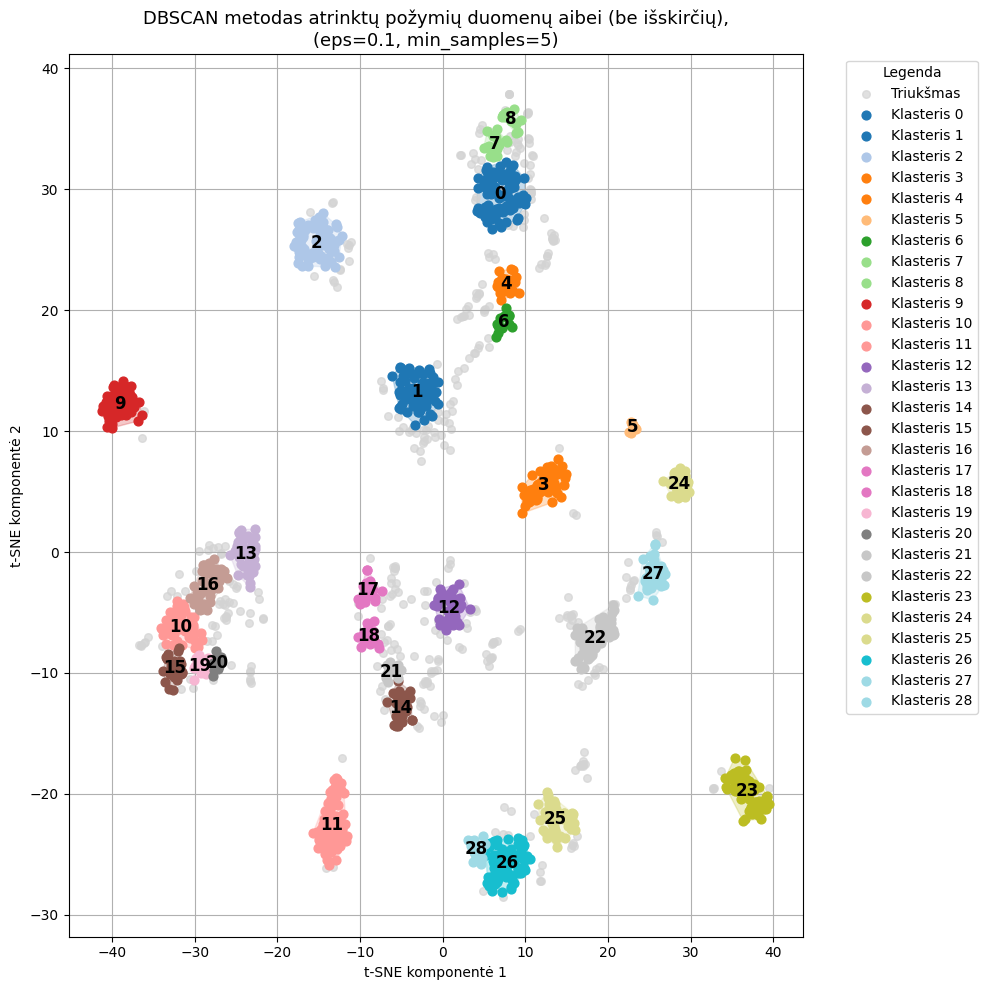

In [81]:
from scipy.spatial import ConvexHull

plt.figure(figsize=(10, 10))

unique_labels = sorted(set(labels))
cluster_ids = [l for l in unique_labels if l != -1]
n_clusters = len(cluster_ids)

# Spalvos tik klasteriams (be -1). Pasirink "tab20" (be pilkų tonų).
# Jei klasterių daug, gali rinktis 'hsv' arba 'turbo'.
cmap = plt.cm.get_cmap('tab20', max(1, n_clusters))
label_to_color = {lab: cmap(i) for i, lab in enumerate(cluster_ids)}

# --- Triukšmas ---
noise_mask = (labels == -1)
if np.any(noise_mask):
    plt.scatter(
        X_tsne[noise_mask, 0],
        X_tsne[noise_mask, 1],
        s=30,
        c="lightgrey",
        label="Triukšmas",
        zorder=1,
        alpha=0.7
    )

# --- Klasteriai ---
for lab in cluster_ids:
    cl_mask = (labels == lab)
    cluster_points = X_tsne[cl_mask]
    color = label_to_color[lab]

    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=40,
        color=color,
        label=f"Klasteris {lab}",
        zorder=2
    )

    if cluster_points.shape[0] >= 3:
        hull = ConvexHull(cluster_points)
        hull_pts = cluster_points[hull.vertices]
        plt.fill(
            hull_pts[:, 0], hull_pts[:, 1],
            alpha=0.25,
            color=color,
            zorder=0
        )
        centroid = cluster_points.mean(axis=0)
        plt.text(
            centroid[0], centroid[1], str(lab),
            fontsize=12, fontweight="bold",
            ha="center", va="center", color="black"
        )

plt.title("DBSCAN metodas atrinktų požymių duomenų aibei (be išskirčių),\n(eps=0.1, min_samples=5)", fontsize=13)
plt.xlabel("t-SNE komponentė 1")
plt.ylabel("t-SNE komponentė 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Legenda")
plt.grid(True)
plt.tight_layout()
plt.show()



--- Procentai (%) klasterio viduje ---
true_label       0       1       2
cluster                           
-1           37.57   31.22   31.22
 0          100.00    0.00    0.00
 1          100.00    0.00    0.00
 2          100.00    0.00    0.00
 3           86.44    6.78    6.78
 4          100.00    0.00    0.00
 5          100.00    0.00    0.00
 6          100.00    0.00    0.00
 7          100.00    0.00    0.00
 8          100.00    0.00    0.00
 9            0.00  100.00    0.00
 10           0.00  100.00    0.00
 11           0.00  100.00    0.00
 12           0.00   26.83   73.17
 13           0.00  100.00    0.00
 14           0.00   93.10    6.90
 15           0.00  100.00    0.00
 16           0.00  100.00    0.00
 17           0.00   84.21   15.79
 18           0.00   58.82   41.18
 19           0.00  100.00    0.00
 20           0.00  100.00    0.00
 21           0.00   90.91    9.09
 22           0.00    0.00  100.00
 23           0.00    0.00  100.00
 24           2

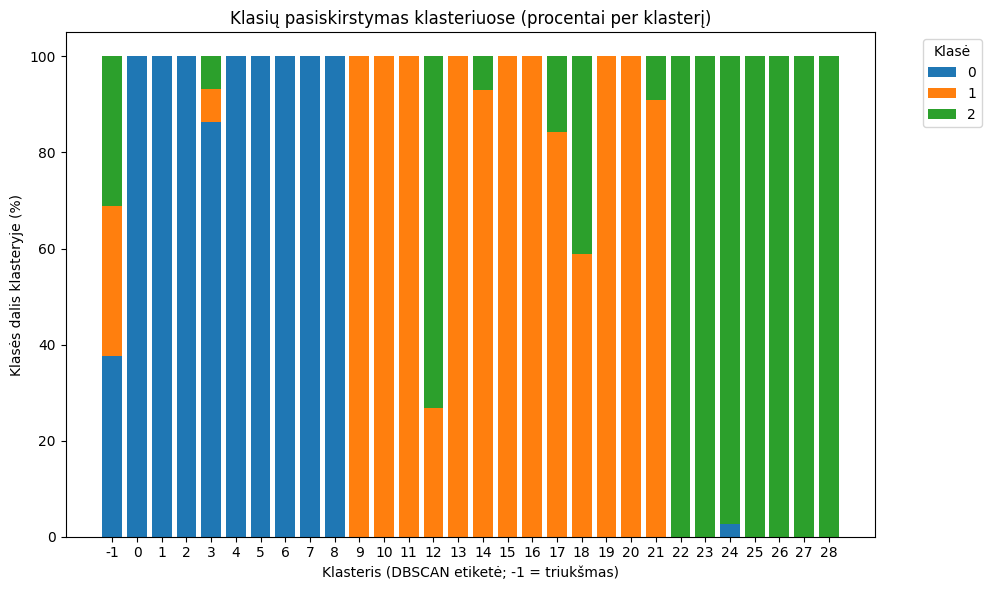

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


has_true = 'label' in df.columns
if not has_true:
    raise ValueError("Failas neturi 'label' stulpelio – negalima sudaryti klasių pasiskirstymo grafiko.")


data_for_summary = pd.DataFrame({
    'cluster': labels,
    'true_label': df['label'].values
})


counts = pd.crosstab(index=data_for_summary['cluster'],
                     columns=data_for_summary['true_label'],
                     dropna=False)


row_sums = counts.sum(axis=1).replace(0, np.nan)
perc = (counts.div(row_sums, axis=0) * 100).fillna(0).round(2)

print("\n--- Procentai (%) klasterio viduje ---")
print(perc)


ordered_idx = sorted(perc.index, key=lambda x: (x != -1, x))  # kad -1 būtų pirmas
perc_plot = perc.loc[ordered_idx]

plt.figure(figsize=(10, 6))
bottom = np.zeros(len(perc_plot))
x = np.arange(len(perc_plot))
class_order = perc_plot.columns.tolist()
for cls in class_order:
    vals = perc_plot[cls].values
    plt.bar(x, vals, bottom=bottom, label=str(cls))
    bottom += vals

plt.xticks(x, [str(i) for i in perc_plot.index])
plt.xlabel("Klasteris (DBSCAN etiketė; -1 = triukšmas)")
plt.ylabel("Klasės dalis klasteryje (%)")
plt.title("Klasių pasiskirstymas klasteriuose (procentai per klasterį)")
plt.legend(title="Klasė", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [83]:
from sklearn.metrics import silhouette_score

mask = labels != -1
if len(set(labels[mask])) > 1:
    sil_score = silhouette_score(X[mask], labels[mask], metric="euclidean")
    print(f"Silhouette koeficientas (be triukšmo): {sil_score:.4f}")
else:
    print("Nepavyko apskaičiuoti silhouette: mažiau nei 2 klasteriai be triukšmo.")


Silhouette koeficientas (be triukšmo): 0.6736


In [10]:
original_data = pd.read_csv("norm_6.csv")
original_data['cluster'] = labels
original_data.to_csv("dbscan_clustered_original_data.csv", index=False)